# 01 - Data Loading & Exploratory Data Analysis (EDA)
Dataset: Telco Customer Churn (Kaggle/IBM)
Tujuan: memahami struktur data, distribusi target, dan data quality issues
sebelum masuk ke tahap data preparation & modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Sesuaikan path jika file CSV kamu berada di lokasi lain
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Perhatikan kolom `TotalCharges` — biasanya terbaca sebagai object/string,
padahal seharusnya numerik. Ini salah satu data quality issue yang akan
kita perbaiki di script preparation.

In [4]:
print("Missing value per kolom:")
print(df.isnull().sum())

Missing value per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# TotalCharges sering berisi string kosong " " untuk customer baru (tenure = 0)
total_charges_blank = df[df["TotalCharges"] == " "]
print("Jumlah baris dengan TotalCharges kosong:", len(total_charges_blank))
total_charges_blank[["customerID", "tenure", "TotalCharges", "Churn"]]

Jumlah baris dengan TotalCharges kosong: 11


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


No     5174
Yes    1869
Name: Churn, dtype: int64

Proporsi (%):
No     73.46
Yes    26.54
Name: Churn, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_18224\1789592104.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


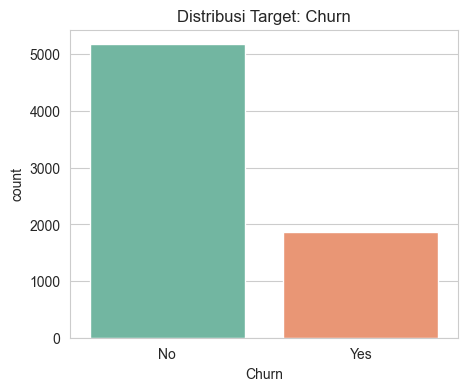

In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print("\nProporsi (%):")
print(churn_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Distribusi Target: Churn")
plt.show()

Catatan penting: dataset ini IMBALANCED.
Kelas "No" (~73%) jauh lebih banyak dari "Yes" (~27%).
Implikasi: jangan gunakan accuracy sebagai metric utama,
dan perlu strategi khusus (class_weight / SMOTE / scale_pos_weight)
saat modeling nanti.

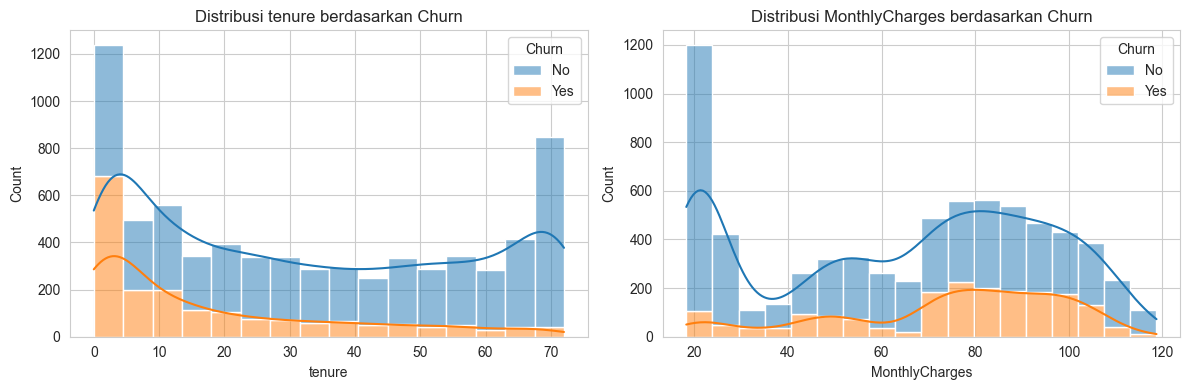

In [7]:
numeric_cols = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, multiple="stack")
    ax.set_title(f"Distribusi {col} berdasarkan Churn")
plt.tight_layout()
plt.show()

Insight yang biasanya muncul:
- Customer dengan tenure rendah (pelanggan baru) cenderung lebih banyak churn.
- Customer dengan MonthlyCharges tinggi juga punya proporsi churn lebih tinggi.

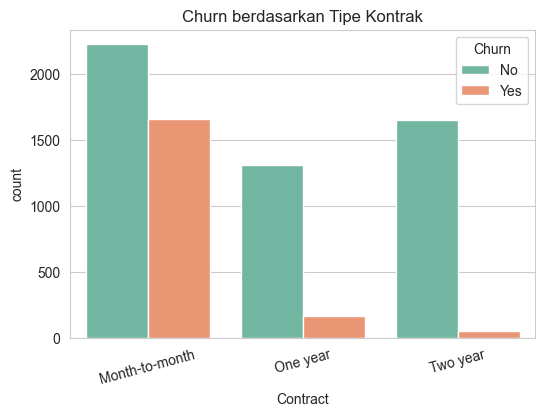

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn berdasarkan Tipe Kontrak")
plt.xticks(rotation=15)
plt.show()

Insight yang biasanya muncul:
- Customer dengan kontrak "Month-to-month" punya churn rate jauh lebih tinggi
  dibanding "One year" atau "Two year".
Insight ini akan jadi salah satu poin rekomendasi bisnis di akhir project.

In [9]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for col in service_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


OnlineSecurity:
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64

OnlineBackup:
No                     3088
Yes                    2429
No internet service    1526
Name: OnlineBackup, dtype: int64

DeviceProtection:
No                     3095
Yes                    2422
No internet service    1526
Name: DeviceProtection, dtype: int64

TechSupport:
No                     3473
Yes                    2044
No internet service    1526
Name: TechSupport, dtype: int64

StreamingTV:
No                     2810
Yes                    2707
No internet service    1526
Name: StreamingTV, dtype: int64

StreamingMovies:
No                     2785
Yes                    2732
No internet service    1526
Name: StreamingMovies, dtype: int64


Catatan: nilai "No internet service" pada kolom-kolom di atas BUKAN missing value,
melainkan kategori valid (customer tidak subscribe internet sama sekali).
Ini perlu diperhatikan saat encoding di tahap data preparation.

## Ringkasan EDA
1. Dataset terdiri dari ~7.043 baris, 21 kolom, 1 target (Churn).
2. Target imbalanced (~27% churn) -> perlu handling khusus saat modeling.
3. Kolom TotalCharges perlu dikonversi ke numerik (11 baris bermasalah).
4. Kolom customerID akan di-drop (tidak prediktif).
5. Tenure rendah, MonthlyCharges tinggi, dan Contract month-to-month
   berasosiasi dengan churn rate lebih tinggi -> kandidat fitur penting.

Lanjut ke: 02_data_preparation.py